# EURUSD — Buy Model (Y₁)

**Purpose:** Train the binary BUY sub-model for EURUSD on the H1 timeframe.  
The label asks: *"would a long trade have hit Take Profit before Stop Loss in the next N bars?"*

**Pipeline overview:**
1. Configuration (paths, ATR params, split dates)
2. Load raw H1 data
3. Validate & inspect the dataset
4. Feature engineering (technical indicators) → `df_features`
5. ATR threshold tuning (class balance exploration on training window)
6. Label generation (SL/TP path-dependent labels) → `df_labeled`
7. Chronological split → `df_train` / `df_val` / `df_test`
8. Walk-forward training — XGBoost + LightGBM base models *(next)*
9. Evaluation (cost-aware metrics)
10. Save trained model to `models_bin/`


---
**Improved version** — incorporates recommendations from `PERFORMANCE_IMPROVEMENT_RECOMMENDATIONS.md`:
- **R1** minimum-support threshold floor (no more noise-driven thresholds)
- **R6** isotonic probability calibration (reliable, reproducible thresholds)
- **R8** soft-vote ensemble of all four models (lower variance)
- **R9** looser feature selection (more candidate features survive)
- **R4** optional Bloomberg macro / rate-differential features (auto-skipped if absent)

All changes are toggleable in-cell. Run top-to-bottom to retrain the BUY model.


In [1]:
#imports code
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Python  : {sys.version}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")


Python  : 3.11.11 | packaged by conda-forge | (main, Mar  3 2025, 20:29:43) [MSC v.1943 64 bit (AMD64)]
NumPy   : 2.0.2
Pandas  : 2.2.2


## 1. Configuration

All paths and key parameters live in one place.  
Change `PAIR` or `TIMEFRAME` here to reuse this notebook for other instruments.


In [2]:
from pathlib import Path

# ── Instrument & timeframe ────────────────────────────────────────────────────
PAIR      = "EURUSD"
TIMEFRAME = "H1"

# ── Data paths ────────────────────────────────────────────────────────────────
# Root of the ml-signal-service folder (two levels up from this notebook)
ROOT = Path("../..").resolve()

RAW_DATA_DIR  = ROOT / "data" / "raw" / "mt5" / TIMEFRAME
RAW_FILE      = RAW_DATA_DIR / f"{PAIR}_{TIMEFRAME}.csv"

MODELS_DIR    = ROOT / "models_bin"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Label parameters ──────────────────────────────────────────────────────────
# TP = 1.5 × ATR above entry, SL = 1.0 × ATR below entry → R:R = 1.5
# Tune these in Section 5 before generating labels.
ATR_PERIOD   = 14     # bars used to compute ATR(14)
ATR_TP_MULT  = 1.5    # take-profit distance = ATR × ATR_TP_MULT
ATR_SL_MULT  = 1.0    # stop-loss distance   = ATR × ATR_SL_MULT
FORWARD_BARS = 6      # how many H1 bars forward to scan for TP/SL hit

# ── Chronological split boundaries ───────────────────────────────────────────
# Edit ONLY here to change split dates — every downstream step reads from these.  TRAIN_START = "2023-06-30"(pr-auc:42); "2025-10-31 23:00:00"; "2025-11-01 00:00:00"
TRAIN_START = "2020-06-30 00:00:00"
TRAIN_END   = "2025-10-31 23:00:00"
VAL_START   = "2025-11-01 00:00:00"
VAL_END     = "2026-03-31 23:00:00"
TEST_START  = "2026-04-01 00:00:00"   # TEST_END = present (all remaining rows)

print(f"Pair       : {PAIR}")
print(f"Timeframe  : {TIMEFRAME}")
print(f"Raw file   : {RAW_FILE}")
print(f"File exists: {RAW_FILE.exists()}")
print(f"Train      : {TRAIN_START}  →  {TRAIN_END}")
print(f"Val        : {VAL_START}  →  {VAL_END}")
print(f"Test       : {TEST_START}  →  present")


Pair       : EURUSD
Timeframe  : H1
Raw file   : C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\data\raw\mt5\H1\EURUSD_H1.csv
File exists: True
Train      : 2020-06-30 00:00:00  →  2025-10-31 23:00:00
Val        : 2025-11-01 00:00:00  →  2026-03-31 23:00:00
Test       : 2026-04-01 00:00:00  →  present


## 2. Load Raw Data

Load the MT5 H1 export for EURUSD. The file contains: `datetime, open, high, low, close, volume`.


In [3]:
df = pd.read_csv(
    RAW_FILE,
    parse_dates=["datetime"],   # parse the datetime column directly on load
)

# Ensure rows are in chronological order (MT5 exports are usually sorted, but let's be safe)
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Rows      : {len(df):,}")
print(f"Columns   : {list(df.columns)}")
print(f"Date range: {df['datetime'].min()}  →  {df['datetime'].max()}")


Rows      : 47,231
Columns   : ['open', 'high', 'low', 'close', 'volume', 'datetime']
Date range: 2019-01-02 00:00:00  →  2026-08-04 21:00:00


## 3. Validate the Dataset

Quick sanity checks before touching anything:
- **dtypes** — datetime must be a proper timestamp, OHLCV must be numeric
- **nulls** — no missing values allowed before feature engineering
- **OHLC logic** — high ≥ open/close ≥ low for every bar
- **Duplicates** — no repeated timestamps


In [4]:
# ── 1. Data types ─────────────────────────────────────────────────────────────
print("=== dtypes ===")
print(df.dtypes)

# ── 2. Null check ─────────────────────────────────────────────────────────────
print("\n=== Null values per column ===")
print(df.isnull().sum())

# ── 3. Duplicate timestamps ───────────────────────────────────────────────────
n_dupes = df["datetime"].duplicated().sum()
print(f"\nDuplicate timestamps : {n_dupes}")

# ── 4. OHLC logic check ───────────────────────────────────────────────────────
# Every bar must satisfy: low <= open <= high  and  low <= close <= high
bad_ohlc = df[
    (df["high"] < df["open"])  |
    (df["high"] < df["close"]) |
    (df["low"]  > df["open"])  |
    (df["low"]  > df["close"])
]
print(f"OHLC logic violations: {len(bad_ohlc)}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
print("\n=== Descriptive statistics ===")
df[["open", "high", "low", "close", "volume"]].describe().round(6)


=== dtypes ===
open               float64
high               float64
low                float64
close              float64
volume             float64
datetime    datetime64[ns]
dtype: object

=== Null values per column ===
open        0
high        0
low         0
close       0
volume      0
datetime    0
dtype: int64

Duplicate timestamps : 0
OHLC logic violations: 0

=== Descriptive statistics ===


,open,high,low,close,volume
count,47231.000000,47231.000000,47231.000000,47231.000000,47231.000000
mean,1.116877,1.117567,1.116201,1.116882,3463.781584
std,0.053110,0.053040,0.053171,0.053109,3420.563804
min,0.953860,0.955880,0.953530,0.953860,1.000000
25%,1.081860,1.082495,1.081300,1.081870,1368.000000
50%,1.114210,1.114730,1.113560,1.114210,2563.000000
75%,1.161390,1.162040,1.160810,1.161395,4370.000000
max,1.233960,1.234890,1.233280,1.233960,75410.000000


In [5]:
# Quick preview — first and last 3 bars
print("=== First 3 bars ===")
display(df.head(3))

print("=== Last 3 bars ===")
display(df.tail(3))


=== First 3 bars ===


,open,high,low,close,volume,datetime
0,1.14624,1.14638,1.14591,1.14603,856.0,2019-01-02 00:00:00
1,1.14616,1.14672,1.14552,1.14605,1821.0,2019-01-02 01:00:00
2,1.14605,1.14620,1.14538,1.14555,1509.0,2019-01-02 02:00:00


=== Last 3 bars ===


,open,high,low,close,volume,datetime
47228,1.15257,1.15260,1.15158,1.15181,2262.0,2026-08-04 19:00:00
47229,1.15181,1.15259,1.15180,1.15234,1565.0,2026-08-04 20:00:00
47230,1.15234,1.15332,1.15221,1.15323,1601.0,2026-08-04 21:00:00


In [6]:
# Distribution of bars per year — useful to spot thin years (data gaps / late exports)
df["year"] = df["datetime"].dt.year

bars_per_year = df.groupby("year").size().rename("bars")
print(bars_per_year.to_string())

# A full trading year on H1 is roughly 6,000–6,500 bars (Mon–Fri, ~24h/day)
# Flag any year below 5,000 as potentially incomplete
low_coverage = bars_per_year[bars_per_year < 5000]
if not low_coverage.empty:
    print(f"\n⚠ Years with < 5,000 bars (possibly incomplete): {low_coverage.index.tolist()}")
else:
    print("\n✓ All years have adequate bar coverage.")

# Drop the helper column — we don't need it in the feature set
df.drop(columns=["year"], inplace=True)


year
2019    6216
2020    6240
2021    6240
2022    6216
2023    6192
2024    6240
2025    6217
2026    3670

⚠ Years with < 5,000 bars (possibly incomplete): [2026]


## 4. Feature Engineering Function

In [7]:

def compute_features(data: pd.DataFrame, pair: str = None) -> pd.DataFrame:
    """
    Compute all technical features from raw H1 OHLCV data.

    Parameters
    ----------
    data : pd.DataFrame
        Must contain columns: datetime, open, high, low, close, volume
        Rows must be sorted chronologically (oldest first).

    Returns
    -------
    pd.DataFrame
        Original columns + all feature columns.
        Rows with NaN (caused by rolling windows at the start) are dropped.
    """
    df = data.copy()

    # ── 1. Time features ──────────────────────────────────────────────────────
    df["hour"]        = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek   # 0=Mon ... 4=Fri
    df["month"]       = df["datetime"].dt.month

    # Cyclical encoding — prevents the model treating 23:00 and 0:00 as far apart
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 5)

    # FX session binary flags (approximate UTC times)
    _h = df["hour"]
    df["session_asian"]   = ((_h >= 0)  & (_h < 7)).astype(int)   # quiet low-liquidity hours
    df["session_london"]  = ((_h >= 7)  & (_h < 16)).astype(int)  # London open
    df["session_ny"]      = ((_h >= 13) & (_h < 22)).astype(int)  # New York open
    df["session_overlap"] = ((_h >= 13) & (_h < 17)).astype(int)  # London-NY overlap (highest liquidity)

    # ── 2. Candle structure ───────────────────────────────────────────────────
    df["body_size"]   = abs(df["close"] - df["open"])
    df["price_range"] = df["high"] - df["low"]
    df["upper_wick"]  = df["high"] - df[["open", "close"]].max(axis=1)
    df["lower_wick"]  = df[["open", "close"]].min(axis=1) - df["low"]
    df["body_ratio"]  = df["body_size"] / df["price_range"].replace(0, np.nan)

    # ── 3. Moving averages ────────────────────────────────────────────────────
    for w in [10, 20, 50]:
        df[f"sma_{w}"] = df["close"].rolling(w).mean()

    for s in [10, 20, 50, 100, 200]:
        df[f"ema_{s}"] = df["close"].ewm(span=s, adjust=False).mean()

    df["close_vs_ema50"]  = (df["close"] - df["ema_50"])  / df["close"]
    df["close_vs_ema200"] = (df["close"] - df["ema_200"]) / df["close"]

    # ── 4. Momentum oscillators ───────────────────────────────────────────────
    delta   = df["close"].diff()
    gain    = delta.clip(lower=0)
    loss    = (-delta).clip(lower=0)
    avg_g   = gain.rolling(14).mean()
    avg_l   = loss.rolling(14).mean()
    rs      = avg_g / avg_l.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))

    low14   = df["low"].rolling(14).min()
    high14  = df["high"].rolling(14).max()
    df["stoch_k"]    = 100 * (df["close"] - low14) / (high14 - low14).replace(0, np.nan)
    df["stoch_d"]    = df["stoch_k"].rolling(3).mean()
    df["williams_r"] = -100 * (high14 - df["close"]) / (high14 - low14).replace(0, np.nan)

    ema12              = df["close"].ewm(span=12, adjust=False).mean()
    ema26              = df["close"].ewm(span=26, adjust=False).mean()
    df["macd"]         = ema12 - ema26
    df["macd_sig"]     = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]    = df["macd"] - df["macd_sig"]
    df["macd_hist_slope"] = df["macd_hist"].diff()

    # ── 5. Volatility ─────────────────────────────────────────────────────────
    high_low   = df["high"] - df["low"]
    high_pc    = (df["high"] - df["close"].shift()).abs()
    low_pc     = (df["low"]  - df["close"].shift()).abs()
    true_range = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
    df["atr_14"] = true_range.rolling(ATR_PERIOD).mean()

    # ATR regime: >1.2 = high vol, <0.8 = low vol, ~1.0 = normal
    df["atr_regime"] = df["atr_14"] / df["atr_14"].rolling(50).mean()

    bb_mid          = df["close"].rolling(20).mean()
    bb_std          = df["close"].rolling(20).std()
    df["bb_upper"]  = bb_mid + 2 * bb_std
    df["bb_lower"]  = bb_mid - 2 * bb_std
    df["bb_width"]  = (df["bb_upper"] - df["bb_lower"]) / bb_mid
    df["bb_pct"]    = (df["close"] - df["bb_lower"]) / (df["bb_upper"] - df["bb_lower"]).replace(0, np.nan)

    for w in [10, 20, 50]:
        df[f"rolling_std_{w}"] = df["close"].rolling(w).std()

    # ── 6. Trend strength ─────────────────────────────────────────────────────
    plus_dm  = df["high"].diff().clip(lower=0)
    minus_dm = (-df["low"].diff()).clip(lower=0)
    plus_dm  = plus_dm.where(plus_dm > minus_dm, 0)
    minus_dm = minus_dm.where(minus_dm > plus_dm, 0)
    atr_adx  = true_range.rolling(14).mean()
    plus_di  = 100 * (plus_dm.rolling(14).mean()  / atr_adx.replace(0, np.nan))
    minus_di = 100 * (minus_dm.rolling(14).mean() / atr_adx.replace(0, np.nan))
    dx       = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    df["adx_14"]   = dx.rolling(14).mean()
    df["plus_di"]  = plus_di
    df["minus_di"] = minus_di

    tp = (df["high"] + df["low"] + df["close"]) / 3
    df["cci_20"]     = (tp - tp.rolling(20).mean()) / (0.015 * tp.rolling(20).std())
    df["roc_10"]     = df["close"].pct_change(10) * 100
    df["momentum_10"] = df["close"] - df["close"].shift(10)

    # ── 7. Volume ─────────────────────────────────────────────────────────────
    df["obv"]          = (np.sign(df["close"].diff()) * df["volume"]).fillna(0).cumsum()
    vol_ma20           = df["volume"].rolling(20).mean()
    df["volume_ratio"] = df["volume"] / vol_ma20.replace(0, np.nan)
    # OBV slope/zscore -- stationary replacements for raw OBV
    obv_vals = df["obv"].values
    df["obv_slope_20"] = np.nan
    for i in range(20, len(obv_vals)):
        slope, _ = np.polyfit(range(20), obv_vals[i-20:i], 1)
        df.iloc[i, df.columns.get_loc("obv_slope_20")] = slope
    df["obv_zscore_100"] = (df["obv"] - df["obv"].rolling(100).mean()) / df["obv"].rolling(100).std()


    # ── 8. Lagged features ────────────────────────────────────────────────────
    for lag in [1, 2, 3, 5]:
        df[f"close_lag_{lag}"]  = df["close"].shift(lag)
        df[f"rsi_lag_{lag}"]    = df["rsi_14"].shift(lag)
        df[f"atr_lag_{lag}"]    = df["atr_14"].shift(lag)
        df[f"volume_lag_{lag}"] = df["volume"].shift(lag)

    # ── 9. Price-change returns ───────────────────────────────────────────────
    for p in [1, 5, 10]:
        df[f"return_{p}b"] = df["close"].pct_change(p)

    # ── 10. D1 context (resampled from H1, no leakage) ───────────────────────
    # Resample H1 to daily OHLCV and compute D1 trend indicators.
    # Values are shifted 1 day before merging: H1 bars on day T see day T-1's
    # D1 close — yesterday's trend information only.
    _d1 = (
        df.set_index("datetime")[["open", "high", "low", "close", "volume"]]
        .resample("1D")
        .agg({"open": "first", "high": "max", "low": "min",
              "close": "last", "volume": "sum"})
        .dropna()
    )
    _d1["d1_ema20"]  = _d1["close"].ewm(span=20, adjust=False).mean()
    _d1["d1_ema50"]  = _d1["close"].ewm(span=50, adjust=False).mean()
    _d1["d1_trend"]  = (_d1["d1_ema20"] > _d1["d1_ema50"]).astype(int)  # 1=uptrend, 0=downtrend
    _dd = _d1["close"].diff()
    _d1["d1_rsi"]    = 100 - 100 / (
        1 + _dd.clip(lower=0).rolling(14).mean()
          / (-_dd).clip(lower=0).rolling(14).mean().replace(0, np.nan)
    )
    _d1["d1_close_vs_ema20"] = (_d1["close"] - _d1["d1_ema20"]) / _d1["close"]

    _d1_cols    = ["d1_ema20", "d1_ema50", "d1_trend", "d1_rsi", "d1_close_vs_ema20"]
    _d1_shifted = (
        _d1[_d1_cols]
        .shift(1)                                         # yesterday's data only
        .reset_index()
        .rename(columns={"datetime": "_d1_date"})
    )

    # ── 11. Intraday context ──────────────────────────────────────────────────
    # Day open = first H1 bar's open for each calendar day.
    # Every bar sees today's opening price (no leakage — it opened before this bar).
    df["_date"]   = df["datetime"].dt.normalize()
    _day_open     = df.groupby("_date")["open"].first().rename("_day_open")
    df            = df.join(_day_open, on="_date")
    df["close_vs_day_open"] = (df["close"] - df["_day_open"]) / df["_day_open"]

    # Merge D1 features back to H1 (matched by midnight timestamp of each day)
    df = df.merge(_d1_shifted, left_on="_date", right_on="_d1_date", how="left")
    df.drop(columns=["_date", "_d1_date", "_day_open"], inplace=True)

    # ── Drop NaN rows ─────────────────────────────────────────────────────────
    # The longest window is EMA(200) + D1 EMA(50 days), so first ~250 bars drop.
    n_before = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    n_dropped = n_before - len(df)
    print(f"Rows dropped (NaN warm-up): {n_dropped:,}  |  Rows remaining: {len(df):,}")
    # Calendar features (optional -- no lookahead)
    if pair:
        try:
            import sys
            from pathlib import Path as _Path
            _root = _Path('../../..').resolve()
            if str(_root / 'frival') not in sys.path:
                sys.path.insert(0, str(_root / 'frival'))
            from data.calendar import compute_calendar_features
            cal_feats = compute_calendar_features(df["datetime"], pair)
            for col in cal_feats.columns:
                df[col] = cal_feats[col].values
            print(f"Calendar features merged: {list(cal_feats.columns)}")
        except Exception as e:
            print(f"Calendar features skipped: {e}")

    return df


In [8]:
# Apply feature engineering to the raw dataframe
df_features = compute_features(df, pair=PAIR)

# ── Quick inspection ──────────────────────────────────────────────────────────
print(f"\nFeature matrix shape : {df_features.shape}")
print(f"Date range           : {df_features['datetime'].min()}  →  {df_features['datetime'].max()}")
print(f"\nAll columns ({len(df_features.columns)}):")
for col in df_features.columns:
    print(f"  {col}")


Rows dropped (NaN warm-up): 361  |  Rows remaining: 46,870
[calendar] Loaded 92,616 events for EURUSD (2007-02-13 -> 2026-12-31)
  HIGH: 7,636  MED+: 35,063  Dev loaded: 40,116
Calendar features merged: ['high_events_next_1h', 'med_events_next_1h', 'high_events_next_4h', 'med_events_next_4h', 'high_events_next_24h', 'med_events_next_24h', 'any_event_next_1h', 'deviation_sum_24h', 'hours_since_last_high', 'is_fomc_day', 'is_ecb_day', 'is_boe_day', 'is_snb_day', 'is_nfp_day']

Feature matrix shape : (46870, 98)
Date range           : 2019-01-23 00:00:00  →  2026-08-04 21:00:00

All columns (98):
  open
  high
  low
  close
  volume
  datetime
  hour
  day_of_week
  month
  hour_sin
  hour_cos
  dow_sin
  dow_cos
  session_asian
  session_london
  session_ny
  session_overlap
  body_size
  price_range
  upper_wick
  lower_wick
  body_ratio
  sma_10
  sma_20
  sma_50
  ema_10
  ema_20
  ema_50
  ema_100
  ema_200
  close_vs_ema50
  close_vs_ema200
  rsi_14
  stoch_k
  stoch_d
  williams_r


In [ ]:
# ── R4 (optional): merge Bloomberg macro / rate-differential features ─────────
# Rate differentials (EUR–US 2Y/10Y) and DXY are the dominant EURUSD drivers in
# the 2020–2025 tightening regime — the most credible source of NEW signal beyond
# price. If a macro CSV is present it is merged as prior-day context (shift(1) →
# no look-ahead). If absent, this cell is a no-op so the notebook still runs.
MACRO_FILE = ROOT / "data" / "macro" / f"{PAIR.lower()}_macro_daily.csv"

if MACRO_FILE.exists():
    _macro = pd.read_csv(MACRO_FILE, parse_dates=["date"]).sort_values("date")
    if "dxy" in _macro.columns:
        _macro["dxy_ret"] = _macro["dxy"].pct_change()
    macro_cols = [c for c in _macro.columns if c != "date"]

    # Shift by one day: an H1 bar on day T only sees macro values as of day T-1.
    _macro[macro_cols] = _macro[macro_cols].shift(1)
    _macro["_mdate"] = _macro["date"].dt.normalize()

    df_features["_mdate"] = df_features["datetime"].dt.normalize()
    df_features = (
        df_features.merge(_macro.drop(columns=["date"]), on="_mdate", how="left")
                   .drop(columns=["_mdate"])
    )
    df_features[macro_cols] = df_features[macro_cols].ffill()
    df_features.dropna(subset=macro_cols, inplace=True)
    df_features.reset_index(drop=True, inplace=True)
    print(f"✓ Merged {len(macro_cols)} macro features: {macro_cols}")
else:
    print(f"ℹ No macro file at {MACRO_FILE.name} — skipping macro features (price-only model).")


## 5. ATR Threshold Tuning

Before locking in `ATR_TP_MULT` and `ATR_SL_MULT`, we explore how different multiplier
combinations affect the class balance **on the training date window only** (2019–2024).

Two things to watch per combination:
- **% BUY** — target range: 20–30%. Below 15% → too rare to train on. Above 40% → signal is noise.
- **Breakeven win rate** — minimum precision the model must achieve to be profitable:
  $$\text{Breakeven} = \frac{SL\_mult}{TP\_mult + SL\_mult}$$

All exploration uses `TRAIN_START`/`TRAIN_END` from config to filter results —
validation and test date windows are never touched.


Fixed SL multiplier = 1.0

 TP mult     R:R    % BUY   Breakeven   In target?
-------------------------------------------------------
    0.50    0.50    58.9%       66.7%            ✗
    0.75    0.75    47.2%       57.1%            ✗
    1.00    1.00    37.5%       50.0%            ✗
    1.25    1.25    30.1%       44.4%            ✓
    1.50    1.50    24.6%       40.0%            ✓
    1.75    1.75    20.2%       36.4%            ✓
    2.00    2.00    16.7%       33.3%            ✓
    2.50    2.50    11.7%       28.6%            ✗
    3.00    3.00     8.4%       25.0%            ✗


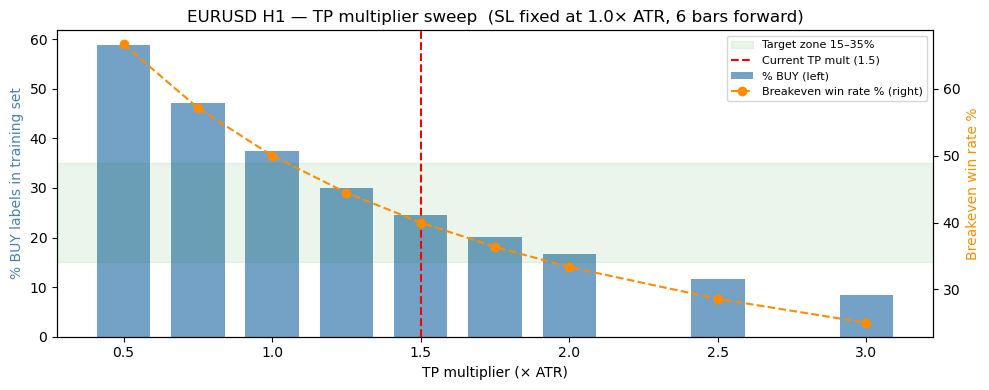

In [9]:
def _label_rate(features_df, train_start, train_end, forward_bars, tp_mult, sl_mult):
    """
    Lightweight helper: compute % BUY labels for a given multiplier pair.
    Labels are generated on the full feature set (so boundary rows are complete),
    then filtered to the training window for the balance calculation.
    """
    close = features_df["close"].values
    high  = features_df["high"].values
    low   = features_df["low"].values
    atr   = features_df["atr_14"].values
    n     = len(features_df)

    labels = np.full(n, np.nan)
    for i in range(n - forward_bars):
        tp_level = close[i] + atr[i] * tp_mult
        sl_level = close[i] - atr[i] * sl_mult
        result = 0
        for j in range(1, forward_bars + 1):
            k = i + j
            tp_hit = high[k] >= tp_level
            sl_hit = low[k]  <= sl_level
            if tp_hit and sl_hit:
                result = 0; break
            elif tp_hit:
                result = 1; break
            elif sl_hit:
                result = 0; break
        labels[i] = result

    # Filter to train window only
    mask  = (features_df["datetime"] >= train_start) & (features_df["datetime"] <= train_end)
    train_labels = labels[mask.values]
    valid = train_labels[~np.isnan(train_labels)]
    return valid.mean() * 100   # % BUY


# ── 1-D sweep: vary TP multiplier, fix SL = 1.0 ──────────────────────────────
tp_candidates = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
sl_fixed      = 1.0

print(f"Fixed SL multiplier = {sl_fixed}\n")
print(f"{'TP mult':>8}  {'R:R':>6}  {'% BUY':>7}  {'Breakeven':>10}  {'In target?':>11}")
print("-" * 55)

tp_sweep_results = []
for tp in tp_candidates:
    pct_buy    = _label_rate(df_features, TRAIN_START, TRAIN_END, FORWARD_BARS, tp, sl_fixed)
    rr         = tp / sl_fixed
    breakeven  = sl_fixed / (tp + sl_fixed) * 100
    in_target  = "✓" if 15 <= pct_buy <= 35 else "✗"
    tp_sweep_results.append((tp, rr, pct_buy, breakeven))
    print(f"{tp:>8.2f}  {rr:>6.2f}  {pct_buy:>6.1f}%  {breakeven:>9.1f}%  {in_target:>11}")

# ── Chart ─────────────────────────────────────────────────────────────────────
tps, rrs, pcts, bes = zip(*tp_sweep_results)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

bars = ax1.bar(tps, pcts, width=0.18, color="steelblue", alpha=0.75, label="% BUY (left)")
ax1.axhspan(15, 35, alpha=0.08, color="green", label="Target zone 15–35%")
ax1.axvline(ATR_TP_MULT, color="red", linestyle="--", linewidth=1.5, label=f"Current TP mult ({ATR_TP_MULT})")
ax2.plot(tps, bes, "o--", color="darkorange", linewidth=1.5, label="Breakeven win rate % (right)")

ax1.set_xlabel("TP multiplier (× ATR)")
ax1.set_ylabel("% BUY labels in training set", color="steelblue")
ax2.set_ylabel("Breakeven win rate %", color="darkorange")
ax1.set_title(f"{PAIR} {TIMEFRAME} — TP multiplier sweep  (SL fixed at {sl_fixed}× ATR, {FORWARD_BARS} bars forward)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


Computing grid (may take ~20 seconds)...
Done.



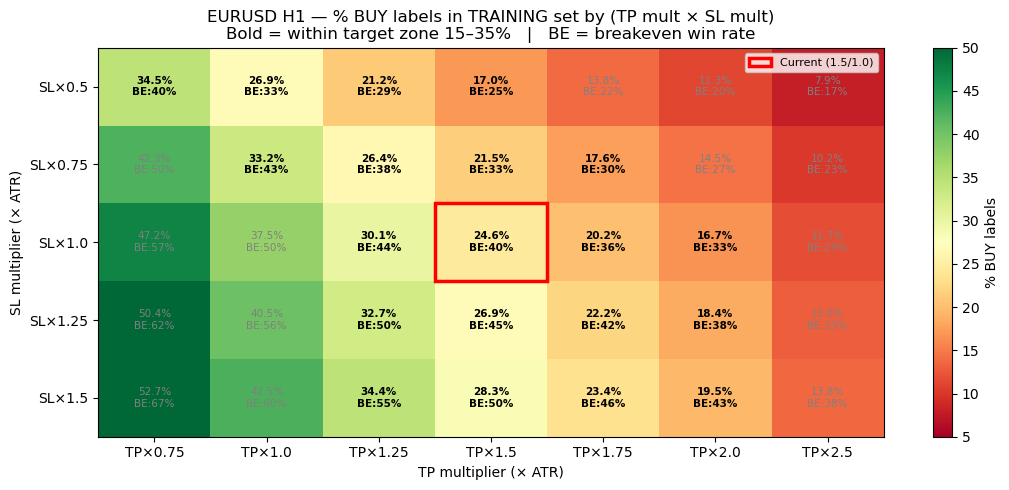


Reading the grid:
  Green cell  = high % BUY  |  Red cell = low % BUY
  Bold values = within target zone (15–35%) — safe to use
  BE          = min precision the model must achieve to be profitable

Current config: TP×1.5 / SL×1.0  →  R:R = 1.5  |  Breakeven = 40.0%


In [10]:
# ── 2-D grid: vary both TP and SL multipliers ────────────────────────────────
tp_grid = [0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5]
sl_grid = [0.5,  0.75, 1.0, 1.25, 1.5]

grid_pct = np.zeros((len(sl_grid), len(tp_grid)))

print("Computing grid (may take ~20 seconds)...")
for i, sl in enumerate(sl_grid):
    for j, tp in enumerate(tp_grid):
        grid_pct[i, j] = _label_rate(
            df_features, TRAIN_START, TRAIN_END, FORWARD_BARS, tp, sl
        )
print("Done.\n")

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

im = ax.imshow(grid_pct, cmap="RdYlGn", vmin=5, vmax=50, aspect="auto")
plt.colorbar(im, ax=ax, label="% BUY labels")

# Annotate each cell with the % value and a breakeven marker
for i, sl in enumerate(sl_grid):
    for j, tp in enumerate(tp_grid):
        pct = grid_pct[i, j]
        be  = sl / (tp + sl) * 100
        in_range = 15 <= pct <= 35
        cell_text = f"{pct:.1f}%\nBE:{be:.0f}%"
        color = "black" if in_range else "grey"
        weight = "bold" if in_range else "normal"
        ax.text(j, i, cell_text, ha="center", va="center",
                fontsize=7.5, color=color, fontweight=weight)

# Mark the currently selected multipliers
if ATR_TP_MULT in tp_grid and ATR_SL_MULT in sl_grid:
    ci = sl_grid.index(ATR_SL_MULT)
    cj = tp_grid.index(ATR_TP_MULT)
    ax.add_patch(plt.Rectangle((cj - 0.5, ci - 0.5), 1, 1,
                                fill=False, edgecolor="red", linewidth=2.5,
                                label=f"Current ({ATR_TP_MULT}/{ATR_SL_MULT})"))
    ax.legend(loc="upper right", fontsize=8)

ax.set_xticks(range(len(tp_grid)))
ax.set_xticklabels([f"TP×{v}" for v in tp_grid])
ax.set_yticks(range(len(sl_grid)))
ax.set_yticklabels([f"SL×{v}" for v in sl_grid])
ax.set_xlabel("TP multiplier (× ATR)")
ax.set_ylabel("SL multiplier (× ATR)")
ax.set_title(
    f"{PAIR} {TIMEFRAME} — % BUY labels in TRAINING set by (TP mult × SL mult)\n"
    f"Bold = within target zone 15–35%   |   BE = breakeven win rate"
)
plt.tight_layout()
plt.show()

print("\nReading the grid:")
print("  Green cell  = high % BUY  |  Red cell = low % BUY")
print("  Bold values = within target zone (15–35%) — safe to use")
print("  BE          = min precision the model must achieve to be profitable")
print(f"\nCurrent config: TP×{ATR_TP_MULT} / SL×{ATR_SL_MULT}  →  "
      f"R:R = {ATR_TP_MULT/ATR_SL_MULT:.1f}  |  "
      f"Breakeven = {ATR_SL_MULT/(ATR_TP_MULT+ATR_SL_MULT)*100:.1f}%")


## 6. Label Generation — Y₁ (BUY)

### What exactly are we predicting?

For each H1 bar `t`, we simulate entering a **long trade at `close[t]`** and ask:  
*"Would this trade have hit Take Profit before Stop Loss within the next 10 hours?"*

### Label mechanics

| Parameter | Formula | Example (ATR = 0.0008) |
|---|---|---|
| Entry price | `close[t]` | 1.0800 |
| TP level | `close[t] + ATR_14[t] × 1.5` | 1.0800 + 0.0012 = **1.0812** |
| SL level | `close[t] − ATR_14[t] × 1.0` | 1.0800 − 0.0008 = **1.0792** |
| Forward window | bars `t+1` → `t+10` | next 10 H1 bars |

Each bar in the window is checked in order (t+1 first, t+10 last):

```
high[t+j] ≥ TP  AND  low[t+j] ≤ SL  → same-bar ambiguity → label = 0  (conservative)
high[t+j] ≥ TP  (only)               → TP hit first       → label = 1  ✓
low[t+j]  ≤ SL  (only)               → SL hit first       → label = 0  ✗
neither hit in all 10 bars            → no outcome         → label = 0
```

**label = 1** → "BUY opportunity — this long trade would have been profitable"  
**label = 0** → "Not a BUY opportunity" (SL hit, timeout, or ambiguous bar)

### Risk-to-reward ratio
$$R:R = \frac{ATR\_TP\_MULT}{ATR\_SL\_MULT} = \frac{1.5}{1.0} = 1.5$$

The threshold is **adaptive per bar** — it scales with ATR, so a label-1 in a volatile session
requires a bigger move than in a quiet session.

### Why label the full dataset then split?
The label for bar `t` uses only the raw `high`/`low` of future bars as the **outcome** to predict.
Those future values never appear as model input features (all features are backward-looking).
There is no data leakage. The last `FORWARD_BARS` rows get `NaN` labels (no complete window) and are dropped.


In [11]:
# ── CHANGE 2: Fix same-bar ambiguity in label generation ─────────────────────
# Original: same-bar TP+SL hit → forced label=0 (conservative but biased)
# Fix: EXCLUDE ambiguous bars entirely — do not train on them at all.
# Recommendation #1: Removing false negatives raises the model's precision ceiling.

def generate_buy_labels(
    data: pd.DataFrame,
    forward_bars: int,
    atr_tp_mult: float,
    atr_sl_mult: float,
) -> pd.DataFrame:
    df = data.copy()
    n = len(df)

    close = df["close"].values
    high  = df["high"].values
    low   = df["low"].values
    atr   = df["atr_14"].values

    # Use NaN as sentinel; ambiguous bars stay NaN and are dropped below
    labels = np.full(n, np.nan)

    for i in range(n - forward_bars):
        entry    = close[i]
        tp_level = entry + atr[i] * atr_tp_mult
        sl_level = entry - atr[i] * atr_sl_mult

        result = np.nan  # ← default: no outcome yet

        for j in range(1, forward_bars + 1):
            k = i + j
            tp_hit = high[k] >= tp_level
            sl_hit = low[k]  <= sl_level

            if tp_hit and sl_hit:
                # ── CHANGED: was result=0; now result=NaN (ambiguous → excluded) ──
                # Same-bar ambiguity: both TP and SL touched in the same H1 bar.
                # We cannot determine which was hit first without sub-H1 data.
                # Forcing label=0 creates false negatives that cap model precision.
                result = np.nan
                break
            elif tp_hit:
                result = 1
                break
            elif sl_hit:
                result = 0
                break
        # If no hit in window, result stays NaN → treated as no-signal (dropped or kept as 0)
        # Only assign a definitive label if we have a clear outcome
        if not np.isnan(result):
            labels[i] = result
        else:
            labels[i] = np.nan  # ambiguous OR timeout → excluded from training

    df["buy_label"] = labels

    n_before = len(df)
    # ── CHANGED: dropna now removes ambiguous bars AND tail rows ──────────────
    df.dropna(subset=["buy_label"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    n_dropped = n_before - len(df)
    print(f"Rows with clean label   : {len(df):,}  (dropped {n_dropped} ambiguous/tail rows)")

    return df

## 7. Chronological Split — Train / Validation / Test

Labels are generated first on the full `df_features`, then the dataset is split by date.
This is the correct order — labels use future price as the **target**, not as a feature,
so there is no data leakage.

| Set | Period | Purpose |
|---|---|---|
| **Train** | 2019-01-01 → 2024-12-31 | Model fitting |
| **Validation** | 2025-01-01 → 2025-12-31 | Model selection, threshold validation |
| **Test** | 2026-01-01 → present | Final hold-out — open only once at the very end |

> Split dates are defined in the **Configuration** cell — change them there, not here.


In [12]:
# Split date constants are defined in the Configuration cell (cell 4).
# The final labeled splits (df_train, df_val, df_test) are created in the cell below
# after labels have been generated — that is the only version used for training.
print(f"Train  : {TRAIN_START}  →  {TRAIN_END}")
print(f"Val    : {VAL_START}  →  {VAL_END}")
print(f"Test   : {TEST_START}  →  present")


Train  : 2020-06-30 00:00:00  →  2025-10-31 23:00:00
Val    : 2025-11-01 00:00:00  →  2026-03-31 23:00:00
Test   : 2026-04-01 00:00:00  →  present


Rows with clean label   : 31,242  (dropped 15628 ambiguous/tail rows)

=== Class balance ===
Split          Total   label=1   label=0    % Buy
--------------------------------------------------
Train         22,145     8,168    13,977    36.9%
Validation     1,787       622     1,165    34.8%
Test           1,511       553       958    36.6%
All           31,242    11,381    19,861    36.4%


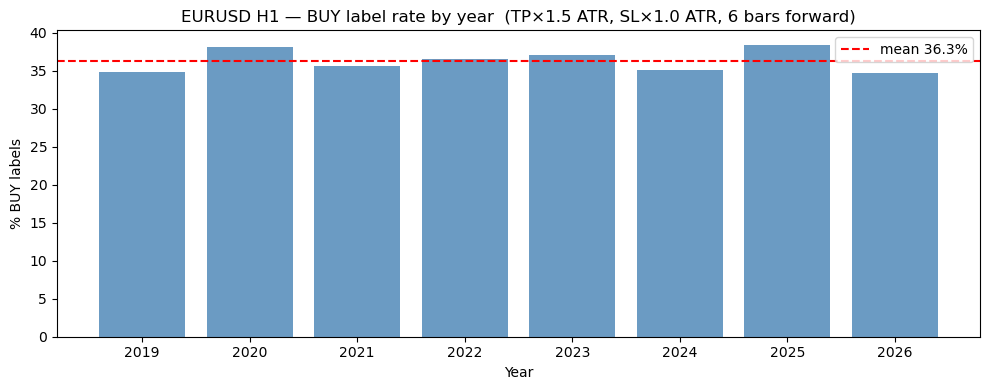

In [13]:
# ── Generate labels on the full feature dataset ───────────────────────────────
df_labeled = generate_buy_labels(
    df_features,
    forward_bars = FORWARD_BARS,
    atr_tp_mult  = ATR_TP_MULT,
    atr_sl_mult  = ATR_SL_MULT,
)

# ── Re-apply chronological splits now that labels exist ──────────────────────
# (same date boundaries as before — just re-filtering the labeled dataframe)
df_train = df_labeled[(df_labeled["datetime"] >= TRAIN_START) & (df_labeled["datetime"] <= TRAIN_END)].copy().reset_index(drop=True)
df_val   = df_labeled[(df_labeled["datetime"] >= VAL_START)   & (df_labeled["datetime"] <= VAL_END)].copy().reset_index(drop=True)
df_test  = df_labeled[df_labeled["datetime"]  >= TEST_START].copy().reset_index(drop=True)

# ── Class balance check ───────────────────────────────────────────────────────
# Target: ~20-30% label=1. Too low → model never fires. Too high → labels are noise.
print("\n=== Class balance ===")
print(f"{'Split':<12} {'Total':>7}  {'label=1':>8}  {'label=0':>8}  {'% Buy':>7}")
print("-" * 50)
for split_name, split_df in [("Train", df_train), ("Validation", df_val), ("Test", df_test), ("All", df_labeled)]:
    n      = len(split_df)
    n_buy  = int(split_df["buy_label"].sum())
    n_no   = n - n_buy
    pct    = n_buy / n * 100
    print(f"{split_name:<12} {n:>7,}  {n_buy:>8,}  {n_no:>8,}  {pct:>6.1f}%")

# ── Visual check: label distribution by year ─────────────────────────────────
df_labeled["year"] = df_labeled["datetime"].dt.year
yearly = df_labeled.groupby("year")["buy_label"].agg(["sum", "count"])
yearly["pct_buy"] = yearly["sum"] / yearly["count"] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly.index, yearly["pct_buy"], color="steelblue", alpha=0.8)
ax.axhline(yearly["pct_buy"].mean(), color="red", linestyle="--", label=f"mean {yearly['pct_buy'].mean():.1f}%")
ax.set_xlabel("Year")
ax.set_ylabel("% BUY labels")
ax.set_title(f"{PAIR} {TIMEFRAME} — BUY label rate by year  (TP×{ATR_TP_MULT} ATR, SL×{ATR_SL_MULT} ATR, {FORWARD_BARS} bars forward)")
ax.legend()
plt.tight_layout()
plt.show()

df_labeled.drop(columns=["year"], inplace=True)


## 8. Training Process

### 8.1 Feature selection

**Method — noise features + voting system.**

We inject random *noise* features (columns with no real predictive value) alongside the
real features, then train several models and read their feature importances. Any real
feature that scores **below the noise** is useless and gets dropped.

Three models vote independently:
- **Random Forest** (tree importance)
- **LightGBM** (tree importance)
- **Logistic Regression** (scaled — `|coef|` as importance)

A feature is kept only if it consistently beats the noise across the models/strategies.

> Everything here is fit on **`df_train` only**. Validation and test sets are never touched
> during feature selection — otherwise we would leak future information.


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

# ── Build the feature list ────────────────────────────────────────────────────
# Everything except raw OHLCV, datetime and the label is a candidate feature.
NON_FEATURES = ["datetime", "open", "high", "low", "close", "volume", "buy_label"]
feature_cols = [c for c in df_train.columns if c not in NON_FEATURES]

# Training matrix — TRAIN SET ONLY
X_train = df_train[feature_cols].copy()
y_train = df_train["buy_label"].astype(int)

print(f"Real features : {len(feature_cols)}")
print(f"X_train shape : {X_train.shape}")
print(f"Positive rate : {y_train.mean()*100:.1f}%")

# ── Generate noise features ───────────────────────────────────────────────────
# Random columns with no real signal. If a real feature can't beat these, drop it.
np.random.seed(42)
n = len(X_train)

noise = {
    "noise_gaussian_1": np.random.normal(0, 1, n),
    "noise_gaussian_2": np.random.normal(0, 2, n),
    "noise_gaussian_3": np.random.normal(5, 1, n),
    "noise_uniform_1":  np.random.uniform(-1, 1, n),
    "noise_uniform_2":  np.random.uniform(-10, 10, n),
    "noise_poisson_1":  np.random.poisson(3, n),
    "noise_poisson_2":  np.random.poisson(6, n),
    "noise_random_walk": np.cumsum(np.random.normal(0, 1, n)),
    "noise_sinusoidal": np.sin(np.linspace(0, 10, n)) + np.random.normal(0, 0.1, n),
}
noise_features = list(noise.keys())

# X augmented with the noise columns
X_noise = X_train.copy()
for name, values in noise.items():
    X_noise[name] = values

print(f"Noise features added : {len(noise_features)}")
print(f"X_noise shape        : {X_noise.shape}")


Real features : 92
X_train shape : (22145, 92)
Positive rate : 36.9%
Noise features added : 9
X_noise shape        : (22145, 101)


In [15]:
# ── Train three models to extract feature importances ─────────────────────────
# class_weight="balanced" handles the ~30/70 imbalance without resampling.

# 1) Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1,
)
rf.fit(X_noise, y_train)

# 2) LightGBM
print("Training LightGBM...")
lgbm = lgb.LGBMClassifier(
    n_estimators=500, max_depth=16, learning_rate=0.05, num_leaves=150,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=42, verbose=-1,
)
lgbm.fit(X_noise, y_train)

# 3) Logistic Regression (linear) — needs scaling + NaN-free input.
#    Coefficients are only comparable when features are on the same scale.
print("Training Logistic Regression...")
X_scaled = X_noise.fillna(X_noise.median()).fillna(0)
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_scaled), columns=X_noise.columns)

logreg = LogisticRegression(
    C=1.0, max_iter=2000, class_weight="balanced", random_state=42,
)
logreg.fit(X_scaled, y_train)

print("✓ All 3 models trained")

# ── Collect importances (one score per feature, per model) ────────────────────
rf_imp     = rf.feature_importances_
lgbm_imp   = lgbm.feature_importances_
logreg_imp = np.abs(logreg.coef_).ravel()   # |coefficient| = linear importance


Training Random Forest...
Training LightGBM...
Training Logistic Regression...
✓ All 3 models trained


In [16]:
# ── Build the importance table ────────────────────────────────────────────────
imp_df = pd.DataFrame({
    "feature":     X_noise.columns,
    "rf_imp":      rf_imp,
    "lgbm_imp":    lgbm_imp,
    "logreg_imp":  logreg_imp,
})
imp_df["is_noise"] = imp_df["feature"].isin(noise_features)

# Weighted average — trees are more reliable here, so they get more weight.
imp_df["avg_imp"] = 0.3 * imp_df["rf_imp"] + 0.6 * imp_df["lgbm_imp"] + 0.1 * imp_df["logreg_imp"]
imp_df = imp_df.sort_values("avg_imp", ascending=False).reset_index(drop=True)

# ── Voting system ─────────────────────────────────────────────────────────────
# Each model "votes" for a feature if its importance is above the given percentile.
VOTING_PERCENTILE = 45   # R9: looser gate keeps more candidate features   # lower = more inclusive, higher = stricter

rf_thr     = np.percentile(rf_imp, VOTING_PERCENTILE)
lgbm_thr   = np.percentile(lgbm_imp, VOTING_PERCENTILE)
logreg_thr = np.percentile(logreg_imp, VOTING_PERCENTILE)

imp_df["rf_vote"]     = (imp_df["rf_imp"]     >= rf_thr).astype(int)
imp_df["lgbm_vote"]   = (imp_df["lgbm_imp"]   >= lgbm_thr).astype(int)
imp_df["logreg_vote"] = (imp_df["logreg_imp"] >= logreg_thr).astype(int)
imp_df["total_votes"] = imp_df[["rf_vote", "lgbm_vote", "logreg_vote"]].sum(axis=1)

print(f"Voting thresholds (top {VOTING_PERCENTILE}%):  "
      f"RF={rf_thr:.5f}  LGBM={lgbm_thr:.5f}  LogReg={logreg_thr:.5f}\n")
print("Top 10 features by average importance:")
print(imp_df[["feature", "avg_imp", "total_votes", "is_noise"]].head(10).to_string(index=False))


Voting thresholds (top 45%):  RF=0.01023  LGBM=686.00000  LogReg=0.02764

Top 10 features by average importance:
              feature     avg_imp  total_votes  is_noise
    deviation_sum_24h 1123.806541            2     False
               adx_14 1009.207048            2     False
       rolling_std_50 1001.410038            3     False
               d1_rsi  985.805636            2     False
                  obv  965.415901            3     False
hours_since_last_high  963.006983            2     False
    noise_random_walk  944.411804            3      True
       obv_zscore_100  917.407528            3     False
           atr_regime  895.215673            3     False
 high_events_next_24h  855.603863            2     False


In [17]:
# ── Noise benchmark ───────────────────────────────────────────────────────────
noise_df = imp_df[imp_df["is_noise"]]
real_df  = imp_df[~imp_df["is_noise"]]

noise_imp_mean = noise_df["avg_imp"].mean()
noise_imp_std  = noise_df["avg_imp"].std()
noise_imp_p70  = np.percentile(noise_df["avg_imp"], 70)
noise_votes_max = noise_df["total_votes"].max()

print(f"Noise benchmark — mean:{noise_imp_mean:.5f}  p70:{noise_imp_p70:.5f}  "
      f"max_votes:{noise_votes_max}\n")

# ── Five selection strategies (each returns a set of real features) ───────────
# A feature that survives several of these is very likely genuine signal.
best_noise_rank = imp_df[imp_df["is_noise"]].index.min()   # rank of top noise feature

strategies = {
    # 1) Ranked above the single best noise feature
    "better_than_best_noise": set(
        real_df[real_df.index < best_noise_rank]["feature"]
    ),
    # 2) Importance above the 70th percentile of noise
    "above_noise_p70": set(
        real_df[real_df["avg_imp"] > noise_imp_p70]["feature"]
    ),
    # 3) More votes than the best noise feature
    "more_votes_than_noise": set(
        real_df[real_df["total_votes"] > noise_votes_max]["feature"]
    ),
    # 4) Above statistical threshold (noise mean + 0.5 std)
    "statistical_threshold": set(
        real_df[real_df["avg_imp"] > noise_imp_mean + 0.5 * noise_imp_std]["feature"]
    ),
    # 5) At least one vote AND above noise mean
    "vote_and_above_mean": set(
        real_df[(real_df["total_votes"] >= 1) & (real_df["avg_imp"] > noise_imp_mean)]["feature"]
    ),
}

for name, feats in strategies.items():
    print(f"  {name:<25} {len(feats)} features")

# ── Consensus — count how many strategies support each feature ────────────────
support = {}
for feats in strategies.values():
    for f in feats:
        support[f] = support.get(f, 0) + 1

MIN_STRATEGY_SUPPORT = 2   # keep features backed by at least this many strategies
selected_features = sorted(
    [f for f, s in support.items() if s >= MIN_STRATEGY_SUPPORT],
    key=lambda f: imp_df.loc[imp_df["feature"] == f, "avg_imp"].iloc[0],
    reverse=True,
)

# Safety net: make sure noise never slips through
selected_features = [f for f in selected_features if f not in noise_features]

print(f"\n✓ Selected features (≥{MIN_STRATEGY_SUPPORT} strategies): {len(selected_features)}")


Noise benchmark — mean:591.40491  p70:666.60409  max_votes:3

  better_than_best_noise    6 features
  above_noise_p70           17 features
  more_votes_than_noise     0 features
  statistical_threshold     15 features
  vote_and_above_mean       28 features

✓ Selected features (≥2 strategies): 17


FEATURE SELECTION RESULTS
Real features tested : 92
Selected             : 17
Reduction            : 82%
Best noise importance : 944.41180

Top 15 selected features:
              feature     avg_imp  total_votes
    deviation_sum_24h 1123.806541            2
               adx_14 1009.207048            2
       rolling_std_50 1001.410038            3
               d1_rsi  985.805636            2
                  obv  965.415901            3
hours_since_last_high  963.006983            2
       obv_zscore_100  917.407528            3
           atr_regime  895.215673            3
 high_events_next_24h  855.603863            2
         obv_slope_20  853.807848            3
    d1_close_vs_ema20  853.210578            3
      close_vs_ema200  824.412168            3
       rolling_std_10  785.408621            3
             minus_di  721.809260            3
              plus_di  720.010110            3

Noise feature positions (for reference):
          feature    avg_imp  total_vote

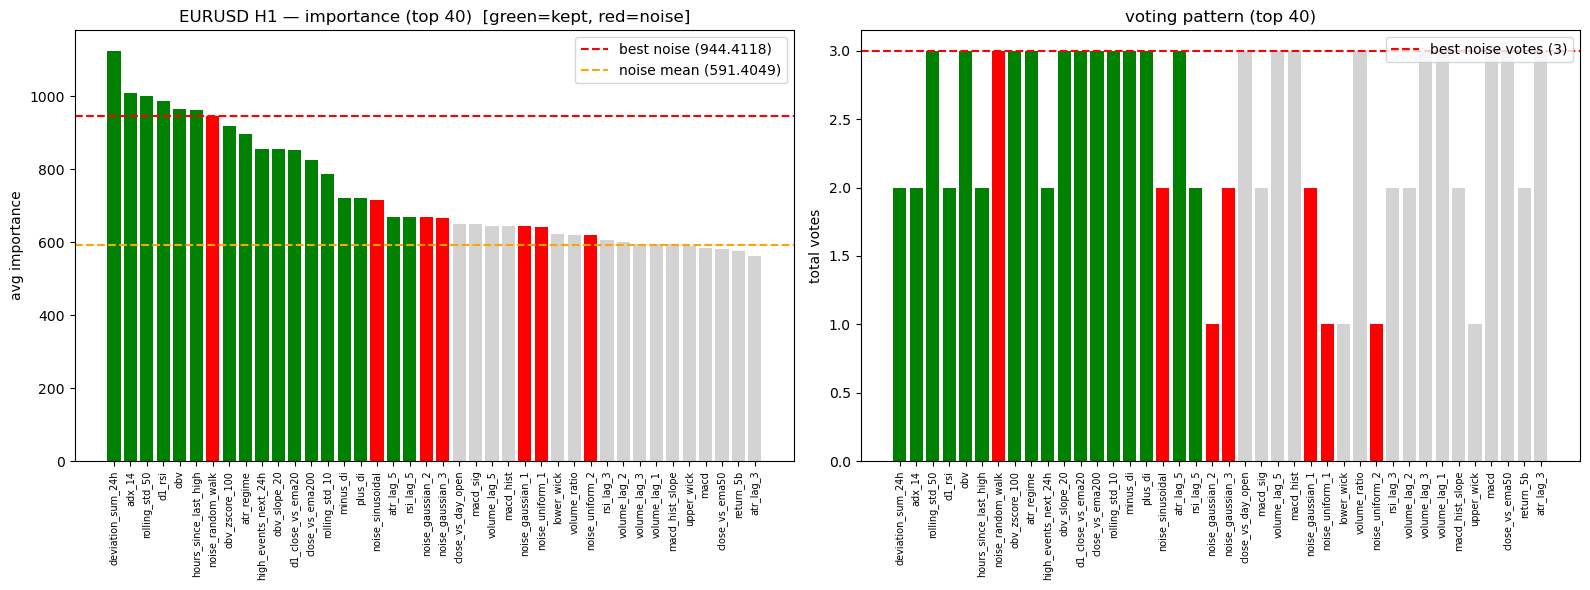

In [18]:
# ── Report ────────────────────────────────────────────────────────────────────
print("=" * 60)
print("FEATURE SELECTION RESULTS")
print("=" * 60)
print(f"Real features tested : {len(feature_cols)}")
print(f"Selected             : {len(selected_features)}")
print(f"Reduction            : {(1 - len(selected_features)/len(feature_cols))*100:.0f}%")
print(f"Best noise importance : {noise_df['avg_imp'].max():.5f}")

selected_report = imp_df[imp_df["feature"].isin(selected_features)]

print("\nTop 15 selected features:")
print(selected_report[["feature", "avg_imp", "total_votes"]].head(15).to_string(index=False))

print("\nNoise feature positions (for reference):")
print(noise_df[["feature", "avg_imp", "total_votes"]].to_string(index=False))

# ── Visualization ─────────────────────────────────────────────────────────────
top = imp_df.head(40)
colors = [
    "green" if f in selected_features else ("red" if noise else "lightgray")
    for f, noise in zip(top["feature"], top["is_noise"])
]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6))

# Left: average importance, with noise benchmarks
axL.bar(range(len(top)), top["avg_imp"], color=colors)
axL.axhline(noise_df["avg_imp"].max(), color="red", linestyle="--",
            label=f"best noise ({noise_df['avg_imp'].max():.4f})")
axL.axhline(noise_imp_mean, color="orange", linestyle="--",
            label=f"noise mean ({noise_imp_mean:.4f})")
axL.set_xticks(range(len(top)))
axL.set_xticklabels(top["feature"], rotation=90, fontsize=7)
axL.set_ylabel("avg importance")
axL.set_title(f"{PAIR} {TIMEFRAME} — importance (top 40)  [green=kept, red=noise]")
axL.legend()

# Right: votes
axR.bar(range(len(top)), top["total_votes"], color=colors)
axR.axhline(noise_votes_max, color="red", linestyle="--",
            label=f"best noise votes ({noise_votes_max})")
axR.set_xticks(range(len(top)))
axR.set_xticklabels(top["feature"], rotation=90, fontsize=7)
axR.set_ylabel("total votes")
axR.set_title("voting pattern (top 40)")
axR.legend()

plt.tight_layout()
plt.show()


In [19]:
# ── Persist the selection for the training phase ──────────────────────────────
# Save both the chosen list and the full importance report next to the model bin.
FEATURES_DIR = ROOT / "data" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

selected_report.to_csv(FEATURES_DIR / f"{PAIR}_{TIMEFRAME}_selected_features.csv", index=False)
imp_df.to_csv(FEATURES_DIR / f"{PAIR}_{TIMEFRAME}_feature_importance_full.csv", index=False)

print(f"✓ Saved {len(selected_features)} selected features to:")
print(f"  {FEATURES_DIR / f'{PAIR}_{TIMEFRAME}_selected_features.csv'}")

# Keep in memory for the next step (model training uses selected_features)
print(f"\nselected_features ready for training ({len(selected_features)} columns).")


✓ Saved 17 selected features to:
  C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\data\features\EURUSD_H1_selected_features.csv

selected_features ready for training (17 columns).


In [ ]:
selected_report

,feature,rf_imp,lgbm_imp,logreg_imp,is_noise,avg_imp,rf_vote,lgbm_vote,logreg_vote,total_votes
0,deviation_sum_24h,0.017891,1873,0.011732,False,1123.806541,1,1,0,2
1,adx_14,0.018152,1682,0.016027,False,1009.207048,1,1,0,2
2,rolling_std_50,0.016722,1669,0.050214,False,1001.410038,1,1,1,3
3,d1_rsi,0.016823,1643,0.005892,False,985.805636,1,1,0,2
4,obv,0.018101,1609,0.104702,False,965.415901,1,1,1,3
5,hours_since_last_high,0.015282,1605,0.023984,False,963.006983,1,1,0,2
7,obv_zscore_100,0.015602,1529,0.028469,False,917.407528,1,1,1,3
8,atr_regime,0.021275,1492,0.092900,False,895.215673,1,1,1,3
9,high_events_next_24h,0.011845,1426,0.003092,False,855.603863,1,1,0,2
10,obv_slope_20,0.015624,1423,0.031607,False,853.807848,1,1,1,3


: 

### 8.2 Model Selection

We pick the best classifier with **nested cross-validation** — an unbiased way to compare models
that also tunes hyperparameters without leaking the validation/test data.

- **Outer CV** — `GroupKFold` by *year* → no year appears in both train and eval within a fold.
- **Inner CV** — `TimeSeriesSplit` → hyperparameter search respects time order.
- **Recency weights** — recent years get more influence (markets drift over time).
- **Optimization metric** — **PR-AUC** (average precision), the right target for an imbalanced,
  precision-focused BUY signal.

Progression: **Logistic Regression** (baseline) → **Random Forest** → **XGBoost** → **LightGBM**.
The model with the best mean outer-fold PR-AUC wins.


In [ ]:
# ── Build model matrices from the selected features ───────────────────────────
# Train is used for nested CV, validation for the final check, test stays sealed.
X_train = df_train[selected_features].fillna(0)
y_train = df_train["buy_label"].astype(int)

X_val = df_val[selected_features].fillna(0)
y_val = df_val["buy_label"].astype(int)

X_test = df_test[selected_features].fillna(0)   # held out — not touched until the very end
y_test = df_test["buy_label"].astype(int)

# ── Purged expanding TimeSeriesSplit (replaces GroupKFold by year) ─────────────
# Expanding windows with a 30-day embargo between train and test.
# Tests the skill that matters in production: training on the past, predicting
# the future. The embargo prevents label leakage from FORWARD_BARS scan and D1
# context shift(1) crossing fold boundaries.
# Assumes df_train is already sorted chronologically (standard after dropna).
train_dates = pd.to_datetime(df_train["datetime"])
n_train = len(df_train)

PURGE_DAYS = 30
OUTER_FOLDS = 5

outer_cv = []
fold_boundaries = []

block_size = n_train // (OUTER_FOLDS + 1)

for fold in range(OUTER_FOLDS):
    test_start_raw = block_size * (fold + 1)
    test_end_raw   = block_size * (fold + 2) if fold < OUTER_FOLDS - 1 else n_train 

    # Purge: slide test_start forward until >= 30 calendar days after last train bar
    last_train_date = train_dates.iloc[test_start_raw - 1]
    purge_threshold = last_train_date + pd.Timedelta(days=PURGE_DAYS)

    test_start = test_start_raw
    while test_start < test_end_raw and train_dates.iloc[test_start] < purge_threshold:
        test_start += 1

    if test_end_raw - test_start < 50:
        continue   # fold too small to evaluate — skip

    train_idx = np.arange(0, test_start)
    test_idx  = np.arange(test_start, test_end_raw)
    outer_cv.append((train_idx, test_idx))
    fold_boundaries.append((train_dates.iloc[test_start], train_dates.iloc[test_end_raw - 1]))

# ── Recency sample weights ────────────────────────────────────────────────────
# Recent years matter more — weight decays ~15% per year back in time.
train_years = df_train["datetime"].dt.year.values

def time_decay_weights(years, decay=0.15):
    years_ago = years.max() - years
    w = np.exp(-decay * years_ago)
    return w * len(w) / w.sum()   # normalise so weights sum to n (sklearn convention)

sample_weights = time_decay_weights(train_years)

print(f"Features : {len(selected_features)}")
print(f"Train    : {X_train.shape}  (pos {y_train.mean()*100:.1f}%)")
print(f"Val      : {X_val.shape}  (pos {y_val.mean()*100:.1f}%)")
print(f"Test     : {X_test.shape}  (sealed)")
print(f"Years    : {sorted(set(train_years))}")
print(f"Outer CV : purged expanding TimeSeriesSplit ({len(outer_cv)} folds, {PURGE_DAYS}-day embargo)")
for i, (start, end) in enumerate(fold_boundaries):
    print(f"  fold {i+1} test: {start.strftime('%Y-%m-%d')} → {end.strftime('%Y-%m-%d')}")


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBClassifier
# NOTE: Previous grid was over-regularised (max_depth=3-4, reg_lambda up to 5.0,
# learning_rate capped at 0.05). This effectively capped the model near linear-
# regression capacity. The grid below gives the search enough range to find the
# right bias-variance trade-off for this dataset: 26 features, ~40k H1 bars,
# ~24% positive class.

# scale_pos_weight balances XGBoost the way class_weight="balanced" does for the others
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "LogReg": {
        "model": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]),
        "params": {},   # baseline — no tuning
    },
    "RandomForest": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [200, 400, 600],
            "max_depth": [10, 15, 20, None],
            "min_samples_leaf": [5, 10, 20, 50],
            "max_features": ["sqrt", "log2", 0.5],
        },
    },
    "XGBoost": {
        "model": XGBClassifier(
            random_state=42, n_jobs=-1, tree_method="hist",
            eval_metric="logloss", scale_pos_weight=pos_weight,
        ),
        "params": {
            "max_depth": [5, 7, 9, 11],
            "learning_rate": [0.05, 0.10, 0.20],
            "n_estimators": [150, 250, 400],
            "subsample": [0.7, 0.8, 0.9],
            "colsample_bytree": [0.7, 0.8, 0.9],
            "reg_lambda": [0.5, 1.0, 5.0],
        },
    },
    "LightGBM": {
        "model": lgb.LGBMClassifier(
            class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1,
        ),
        "params": {
            "max_depth": [6, 8, 10, 12],
            "num_leaves": [15, 31, 63, 127],
            "learning_rate": [0.05, 0.10, 0.20],
            "n_estimators": [150, 250, 400],
            "subsample": [0.8, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.8, 0.9],
            "reg_lambda": [0.1, 0.5, 1.0, 5.0],
            "min_child_samples": [10, 20, 50],
        },
    },
}

# ── CV strategy ───────────────────────────────────────────────────────────────
INNER_FOLDS = 4
SEARCH_ITERS = 65   # wider grid needs more draws to explore

inner_cv = TimeSeriesSplit(n_splits=INNER_FOLDS)

print(f"Inner CV : TimeSeriesSplit({INNER_FOLDS})")
print(f"Search   : {SEARCH_ITERS} iters | optimizing PR-AUC (average_precision)")
print(f"XGB scale_pos_weight = {pos_weight:.2f}")

In [ ]:
from sklearn.metrics import average_precision_score


def nested_cv(model, params, X, y, weights, name):
    """
    Nested cross-validation for one classifier.
    Inner loop tunes hyperparameters (RandomizedSearchCV, PR-AUC).
    Outer loop uses purged expanding TimeSeriesSplit — train on past, test on future.
    Returns scores + best params per fold.
    """
    outer_scores, best_params_per_fold = [], []

    for fold, (tr, te) in enumerate(outer_cv, 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        w_tr = weights[tr]

        if params:  # tree models — tune hyperparameters on the inner split
            search = RandomizedSearchCV(
                model, params, n_iter=SEARCH_ITERS, cv=inner_cv,
                scoring="average_precision", n_jobs=-1, random_state=42,
            )
            search.fit(X_tr, y_tr, sample_weight=w_tr)
            best = search.best_estimator_
            best_params_per_fold.append(search.best_params_)
        else:       # baseline — no tuning
            best = model.fit(X_tr, y_tr)
            best_params_per_fold.append({})

        # PR-AUC on the untouched outer fold
        proba = best.predict_proba(X_te)[:, 1]
        outer_scores.append(average_precision_score(y_te, proba))
        print(f"   fold {fold}/{len(outer_cv)}  PR-AUC = {outer_scores[-1]:.3f}")

    print(f"   → {name}: PR-AUC {np.mean(outer_scores):.3f} ± {np.std(outer_scores):.3f}")
    return {
        "name": name,
        "pr_auc_mean": np.mean(outer_scores),
        "pr_auc_std": np.std(outer_scores),
        "best_params_per_fold": best_params_per_fold,
    }


print("✓ nested_cv() ready")

In [ ]:
# ── Run nested CV for every model ─────────────────────────────────────────────
# Note: the tree searches can take a few minutes.
cv_results = {}
for name, cfg in models.items():
    print(f"\n{name}")
    cv_results[name] = nested_cv(
        cfg["model"], cfg["params"], X_train, y_train, sample_weights, name,
    )

# ── Comparison table (higher PR-AUC is better) ────────────────────────────────
comparison = (
    pd.DataFrame([
        {"model": r["name"], "pr_auc": r["pr_auc_mean"], "std": r["pr_auc_std"]}
        for r in cv_results.values()
    ])
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

# Baseline reference = prevalence (a random model scores ≈ positive rate)
baseline_pr = y_train.mean()

print("\n=== Model comparison (PR-AUC) ===")
print(comparison.round(3).to_string(index=False))
print(f"\nRandom baseline PR-AUC ≈ {baseline_pr:.3f} (positive rate)")

best_model_name = comparison.iloc[0]["model"]
print(f"\n🏆 Best model: {best_model_name}")

In [ ]:
# ── Manual model override ─────────────────────────────────────────────────────
# By default the model with the best CV PR-AUC is used automatically.
# To force a different model, set MANUAL_MODEL to one of the names below and
# re-run this cell + everything after it.
#
# Available names (must match exactly):
#   "LogReg"        "RandomForest"        "XGBoost"        "LightGBM"
#
MANUAL_MODEL =  None        # ← change to e.g. "LightGBM" to override

# ── Apply override (or keep automatic winner) ─────────────────────────────────
if MANUAL_MODEL is not None:
    if MANUAL_MODEL not in cv_results:
        raise ValueError(f"Unknown model '{MANUAL_MODEL}'. Choose from: {list(cv_results.keys())}")
    best_model_name = MANUAL_MODEL
    print(f"⚠ Manual override active → using {best_model_name}")
else:
    print(f"✓ Auto-selected best model → {best_model_name}")

# Show the CV score for the chosen model
chosen = cv_results[best_model_name]
print(f"\n  CV PR-AUC : {chosen['pr_auc_mean']:.3f} ± {chosen['pr_auc_std']:.3f}")
print(f"\nModel comparison for reference:")
print(comparison.round(3).to_string(index=False))

In [ ]:
# ── Final model: isotonic calibration (R6) + optional soft-vote ensemble (R8) ──
from collections import Counter
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix,
)

# ── Toggles ───────────────────────────────────────────────────────────────────
USE_CALIBRATION = True    # R6: isotonic calibration -> reliable, monotonic probabilities
USE_ENSEMBLE    = True    # R8: average all four calibrated models instead of one winner
CALIB_CV        = 3       # internal CV folds for the calibrator (fit on TRAIN only)


def most_frequent_params(params_list):
    """Aggregate the hyperparameters most often chosen across the outer folds."""
    final = {}
    for key in {k for p in params_list for k in p}:
        vals = [p[key] for p in params_list if key in p]
        final[key] = Counter(vals).most_common(1)[0][0]
    return final


def build_tuned(name):
    """Fresh estimator for `name` with its most-frequent CV hyperparameters applied."""
    est = models[name]["model"]
    params = most_frequent_params(cv_results[name]["best_params_per_fold"])
    if params:
        est.set_params(**params)
    return est, params


def make_calibrated(est):
    """R6: wrap an estimator in isotonic calibration (internal CV on train)."""
    return CalibratedClassifierCV(est, method="isotonic", cv=CALIB_CV) if USE_CALIBRATION else est


# ── Assemble the final estimator (all sklearn -> picklable for the combiner) ──
if USE_ENSEMBLE:
    estimators = []
    for name in models:
        base, params = build_tuned(name)
        estimators.append((name, make_calibrated(base)))
        print(f"  {name:<12} params: {params if params else '(baseline)'}")
    final_model = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)
    final_model.fit(X_train, y_train)          # ensemble of pipelines -> fit without sample_weight
    best_model_name = "Ensemble"
    print("\n✓ Final model = soft-vote ensemble of 4 calibrated models")
else:
    base, params = build_tuned(best_model_name)
    final_model = make_calibrated(base)
    try:                                       # apply recency weights where supported
        final_model.fit(X_train, y_train, sample_weight=sample_weights)
    except TypeError:
        final_model.fit(X_train, y_train)
    print(f"Final hyperparameters: {params}")
    print(f"\n✓ Final model = {best_model_name}{' (calibrated)' if USE_CALIBRATION else ''}")

# ── Validation performance ────────────────────────────────────────────────────
val_proba = final_model.predict_proba(X_val)[:, 1]
val_pred  = (val_proba >= 0.5).astype(int)
breakeven = ATR_SL_MULT / (ATR_TP_MULT + ATR_SL_MULT)   # precision the model must beat

# NOTE: 0.5 is only a reference point — the true operating threshold is
# calibrated in the next cell. A well-calibrated model on a ~25% base-rate
# problem rarely exceeds 0.5, so these figures look conservative by design.
print(f"\n=== Validation performance (@0.5 reference) — {best_model_name} ===")
print(f"Precision : {precision_score(y_val, val_pred, zero_division=0):.3f}   (breakeven ≈ {breakeven:.3f})")
print(f"Recall    : {recall_score(y_val, val_pred, zero_division=0):.3f}")
print(f"F1        : {f1_score(y_val, val_pred, zero_division=0):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y_val, val_proba):.3f}")
print(f"PR-AUC    : {average_precision_score(y_val, val_proba):.3f}")
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_val, val_pred))

### 8.3 Threshold Calibration

Precision at threshold 0.5 is **below the breakeven (0.40)** — the model fires on too many
low-confidence bars. Raising the threshold trades recall for precision.

We scan every threshold and find the one where **precision ≥ breakeven** with the most signals.


In [ ]:
from sklearn.metrics import precision_recall_curve

# ── R1: threshold calibration with a minimum-support floor ────────────────────
# The old rule ("highest recall with precision >= breakeven") could latch onto a
# handful of lucky bars (e.g. 7 signals) that never generalize to the test set.
# We now require a minimum number of validation signals before a threshold is
# eligible, then pick the one maximizing precision x log(signals).
MIN_VAL_SIGNALS = 50    # ~0.5 signals/day over the validation window

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
trading_days = len(y_val) / 24

rows = []
for thr, prec, rec in zip(thresholds, precisions[:-1], recalls[:-1]):
    n_signals = int((val_proba >= thr).sum())
    if n_signals == 0:
        continue
    rows.append({
        "threshold": round(float(thr), 3),
        "precision": round(float(prec), 3),
        "recall":    round(float(rec), 3),
        "n_signals": n_signals,
        "signals_per_day": round(n_signals / trading_days, 2),
    })
cal_df = pd.DataFrame(rows)

eligible = cal_df[cal_df["n_signals"] >= MIN_VAL_SIGNALS].copy()
if not eligible.empty:
    above = eligible[eligible["precision"] >= breakeven]
    if not above.empty:
        # A profitable region exists. Because the strategy has a FIXED breakeven,
        # what drives EV is the precision MARGIN over breakeven — so rank by
        # (precision - breakeven) * log(signals). The log term keeps a mild reward
        # for volume without letting it override precision. This avoids the volume
        # bias of precision*log(signals), which picked SELL thr 0.295 (val prec 0.425)
        # over 0.306 (val prec 0.447); 0.295 then slipped to 0.391 (below breakeven)
        # on the sealed test, while the higher-precision 0.306 point holds up better.
        pool = above.assign(score=(above["precision"] - breakeven) * np.log(above["n_signals"]))
    else:
        # No threshold clears breakeven: the model is a pure ranker. Keep the old
        # volume-weighted pick and gate it downstream via the combiner EV/CI check.
        pool = eligible.assign(score=eligible["precision"] * np.log(eligible["n_signals"]))
    best  = pool.sort_values("score", ascending=False).iloc[0]
    OPTIMAL_THRESHOLD = float(best["threshold"])
    reached = best["precision"] >= breakeven
    print(f"Breakeven          : {breakeven:.3f}")
    print(f"Min signals floor  : {MIN_VAL_SIGNALS}")
    print(f"Optimal threshold  : {OPTIMAL_THRESHOLD}")
    note = "" if reached else "  ⚠ below breakeven — model is a ranker; gate downstream"
    print(f"Precision @ optimal: {best['precision']:.3f}{note}")
    print(f"Recall    @ optimal: {best['recall']:.3f}")
    print(f"Signals            : {int(best['n_signals'])} ({best['signals_per_day']:.2f}/day)")
    print("\nTop eligible thresholds:")
    print(pool.sort_values("score", ascending=False)
              .drop(columns="score").head(10).to_string(index=False))
else:
    OPTIMAL_THRESHOLD = 0.5
    print(f"⚠ No threshold reaches {MIN_VAL_SIGNALS} signals on validation — falling back to 0.5.")

# ── Precision-recall curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(recalls[:-1], precisions[:-1], color="steelblue", lw=1.5, label="PR curve")
ax.axhline(breakeven, color="red", ls="--", lw=1.5, label=f"Breakeven {breakeven:.2f}")
ax.axhline(y_val.mean(), color="gray", ls=":", lw=1, label=f"Base rate {y_val.mean():.2f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"{PAIR} {TIMEFRAME} — Precision-Recall (validation)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# ── Test set predictions — probability view ───────────────────────────────────
test_proba = final_model.predict_proba(X_test)

test_results_buy = df_test[["datetime", "close", "buy_label"]].copy()
test_results_buy["set_type"]    = "test"
test_results_buy["prob_no_buy"] = test_proba[:, 0]   # P(label=0)
test_results_buy["prob_buy"]    = test_proba[:, 1]   # P(label=1)
test_results_buy["signal"]      = (test_results_buy["prob_buy"] >= OPTIMAL_THRESHOLD).astype(int)

print(f"Test set  : {len(test_results_buy):,} bars")
print(f"Signals   : {test_results_buy['signal'].sum()} ({test_results_buy['signal'].mean()*100:.1f}%)")
print(f"Threshold : {OPTIMAL_THRESHOLD}")
print()
display(test_results_buy[test_results_buy["signal"] == 1].head(20))

In [ ]:
import joblib

# ── Save the trained model + the feature list it expects ──────────────────────
# The bundle includes the optimal threshold so inference uses the right cutoff.
model_path = MODELS_DIR / f"{PAIR}_{TIMEFRAME}_buy_{best_model_name}.joblib"
joblib.dump(
    {
        "model": final_model,
        "features": selected_features,
        "threshold": OPTIMAL_THRESHOLD,   # use this, not 0.5, for BUY signals
        "atr_tp_mult": ATR_TP_MULT,
        "atr_sl_mult": ATR_SL_MULT,
        "forward_bars": FORWARD_BARS,
    },
    model_path,
)

print(f"✓ Saved model bundle → {model_path}")
print(f"  model     : {best_model_name}")
print(f"  features  : {len(selected_features)}")
print(f"  threshold : {OPTIMAL_THRESHOLD}  (calibrated for precision ≥ {breakeven:.2f})")
